In [1]:
import importlib
import pandas as pd
import preprocess_behav2p as preprocess
import analysis_functions as af
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter
from scipy import stats
import os
import pickle
from matplotlib.animation import FuncAnimation
from io_utils import save_pickle, load_pickle
import init_vars as iv
import visualize as viz
from scipy.stats import ttest_rel
import scipy
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from scipy.ndimage import gaussian_filter1d

d:\anaconda\envs\preprocessData\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import importlib, io_utils
importlib.reload(io_utils)
from io_utils import save_pickle, load_pickle

In [18]:
# RELOAD 
importlib.reload(preprocess)
data_dir = r'Y:\\public\\projects\SaEl_20220201_VIP\\2pdata\subj_record.xlsx'
sheet_name = 'LC_DREADDs'
table = pd.read_excel(data_dir, sheet_name=sheet_name)
comb = {}
neuropil_factor = 0.3
tri_perc = 1
for ani in [4,5]:
    # Run preprocessing for each animal/session
    ani, pp = preprocess.main(ani, table,sheet_name, neuropil_factor, tri_perc,basesub=1, roitype='suite2p')
    comb[ani] = {
        'n_gratings': pp.n_gratings,
        'unpred_trials': pp.unpred_trials,
        'pred_trials': pp.pred_trials,
        'trial_start_indices': pp.trial_start_indices,
        'grating_indices': pp.grating_indices,
        'dff_Zscore': pp.dff_Zscore,
        'n_planes': pp.n_planes,
        'n_trial': pp.n_trials,
        'aligned_data': pp.aligned_data,
        'reward_indices': pp.reward_indices,
        'activity': pp.activity,
        'TC': pp.TC,
        'position': pp.position,
        'position_tunnel': pp.position_tunnel,
        'speed': pp.speed,
        'trial_type': pp.trial_types,
        'pupil': pp.pupil,
        'lick': pp.lick
    }

data = {}
importlib.reload(iv)
for ani in comb.keys():
    data[ani] ={}
    data[ani]['aligned_data'] = comb[ani]['aligned_data']
    data[ani]['activity'] = comb[ani]['activity']
    data[ani]['unpred_trials'] = comb[ani]['unpred_trials']
    data[ani]['pred_trials'] = comb[ani]['pred_trials']
    data[ani]['dff_Zscore'] = comb[ani]['dff_Zscore']
    data[ani]['trial_start_indices'] = comb[ani]['trial_start_indices']
    data[ani]['type'] = table.iloc[ani][3]
    data[ani]['grating_indices']= comb[ani]['grating_indices']
    data[ani]['reward_indices']= comb[ani]['reward_indices']
    data[ani]['n_gratings'] = comb[ani]['n_gratings']
    data[ani]['n_trial'] = comb[ani]['n_trial']
    if table.iloc[ani][1] == 1:
        data[ani]['position_tunnel'] = comb[ani]['position_tunnel']
        data[ani]['position'] = comb[ani]['position']
        data[ani]['speed'] = comb[ani]['speed']
        data[ani]['lick'] = comb[ani]['lick']
        data[ani]['pupil'] = comb[ani]['pupil']
    else:
        data[ani]['position'] = comb[ani]['aligned_data' ]['Averaged_Position']
        try:
            data[ani]['pupil'] = comb[ani]['aligned_data']['pupil_diameter']
            data[ani] = iv.process_pupil(data[ani])
        except KeyError:
            data[ani]['pupil'] = None

        data[ani]['speed'] = comb[ani]['aligned_data']['Speed_Absolute']
        data[ani] = iv.process_speed(data[ani])

    save_pickle(data[ani], "all_data", base_path=table.iloc[ani][2])

R2=0.9999999922470187 ---- Slope=1.0000167188209355 ---- intercept=0.7651887134620665
Using DLC file: PupilCamera_CameraVideoDLC_resnet50_pupil-setup2-bonsaiJan21shuffle1_500000.csv
Detected 1 excess frames in the downsampled data. Discarding these frames.
bonsai done
R2=0.9999999947148255 ---- Slope=1.000013230245732 ---- intercept=0.7012166481567874
Using DLC file: PupilCamera_CameraVideoDLC_resnet50_pupil-setup2-bonsaiJan21shuffle1_500000.csv
Detected 1 excess frames in the downsampled data. Discarding these frames.
bonsai done


In [2]:
# LOAD DATA
importlib.reload(preprocess)
data_dir = r'Y:\\public\\projects\SaEl_20220201_VIP\\2pdata\subj_record.xlsx'
sheet_name = 'LC_DREADDs'
table = pd.read_excel(data_dir, sheet_name=sheet_name)
data = {}
tri_perc = 1
ani_range = [4,5]
for ani in ani_range:
    data[ani] = load_pickle('all_data',base_path=table.iloc[ani][2])

In [ ]:
# Dreadds1 Session E (CNO) and D (saline)
# Session E: ani=4 / Session D: ani=5

In [53]:
# find responsive cells
blo1 = {}
blo2 = {}
blo1[4] = slice(0,160)
blo1[5] = slice(0,170)
blo2[4] = slice(160,None)
blo2[5] = slice(170,None)

prestim_frames = slice(10,15)
poststim_frames = slice(23,33)
sig_cells = {}
for ani in ani_range:
    sig_cells[ani] = {}
    for grat in ['gr_1','gr_2','X']:
        if grat == 'gr_1':
            sig_cells_blo1 = af.find_significant_neurons_threshold(data[ani]['activity'][grat],blo1[ani],0.5,prestim_frames,poststim_frames)[0]
            sig_cells_blo2 = af.find_significant_neurons_threshold(data[ani]['activity'][grat],blo2[ani],0.5,prestim_frames,poststim_frames)[0]
            sig_cells[ani][grat] = np.union1d(sig_cells_blo1,sig_cells_blo2)  # find sig cells in either blo1 or blo2 or both      
        if grat == 'gr_2':
            trials = data[ani]['pred_trials']
            sig_cells[ani][grat] = af.find_significant_neurons_threshold(data[ani]['activity'][grat],trials,0.5,prestim_frames,poststim_frames)[0]
        if grat == 'X':
            trials = np.array(data[ani]['unpred_trials']['gr_2'])
            trials_blo1 = trials[trials<blo1[ani].stop] # blo1 unexp trials
            trials_blo2 = trials[trials>= blo1[ani].stop] # blo2 unexp trials
            sig_cells_blo1 = af.find_significant_neurons_threshold(data[ani]['activity']['gr_2'],trials_blo1,0.5,prestim_frames,poststim_frames)[0]
            sig_cells_blo2 = af.find_significant_neurons_threshold(data[ani]['activity']['gr_2'],trials_blo2,0.5,prestim_frames,poststim_frames)[0]
            sig_cells[ani][grat] = np.union1d(sig_cells_blo1,sig_cells_blo2)

In [54]:
# get baseline-subtracted pupil
baseline_frames = slice(0,10)  # 1s pre-event window (onset at frame 19)
for ani in ani_range:
    if data[ani].get('pupil_rel') is None:
        continue
    data[ani]['pupil_rel_bs'] = {}
    for grat in data[ani]['pupil_rel']:
        epochs = data[ani]['pupil_rel'][grat].copy().astype(float)
        bad = np.mean(np.isnan(epochs), axis=1) > 0.5
        epochs[bad] = np.nan  # remove the trials that contains more than 50% NaN
        baseline_mean = np.nanmean(epochs[:, baseline_frames], axis=1, keepdims=True)
        data[ani]['pupil_rel_bs'][grat] = epochs - baseline_mean

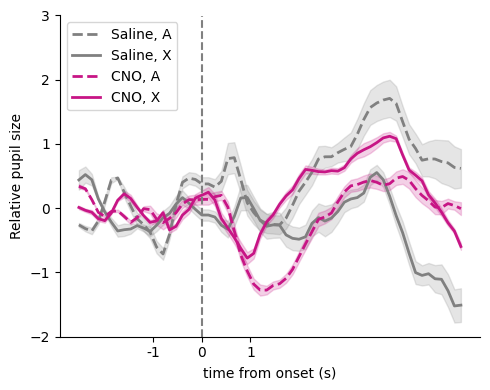

In [290]:
# Pupil dynamics
tst = [4]
ctl = [5]

unexp_tri = {}
for ani in ani_range:
    unexp_tri[ani] = data[ani]['unpred_trials']['gr_2']

fig,ax = plt.subplots(1,1, figsize = (5,4))
pupil_ctl_A = []
pupil_cno_A = []
grat = 'gr_1'
for ani in ctl:
    trials = np.array(unexp_tri[ani][:4])
    pupil_ctl_A.append(data[ani]['pupil_rel_bs'][grat][trials])
for ani in tst: 
    trials = np.array(unexp_tri[ani][:4])   
    pupil_cno_A.append(data[ani]['pupil_rel_bs'][grat][trials])


pupil_ctl_X = []
pupil_cno_X = []
grat = 'gr_2'
for ani in ctl:
    trials = np.array(unexp_tri[ani][:4])
    pupil_ctl_X.append(data[ani]['pupil_rel_bs'][grat][trials])
for ani in tst:    
    trials = np.array(unexp_tri[ani][:4])
    pupil_cno_X.append(data[ani]['pupil_rel_bs'][grat][trials])

viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(pupil_ctl_A),color='grey',label='Saline, A',style='dash')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(pupil_ctl_X),color='grey',label='Saline, X')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(pupil_cno_A),color='mediumvioletred',label='CNO, A',style='dash')
viz.plot_shaded_error(ax,x_vals=np.arange(60),data=np.vstack(pupil_cno_X),color='mediumvioletred',label='CNO, X')

ax.axvline(19, linestyle='--', color='grey')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Relative pupil size')
ax.set_yticks([-2, -1, 0, 1,2,3])
ax.set_xlabel('time from onset (s)')
ax.set_xticks([11.5, 19, 26.5])
ax.set_xticklabels(['-1', '0', '1'])
# ax.set_title('Pupil Response')
plt.tight_layout()
plt.show()

Text(0.5, 0, 'time from onset (s)')

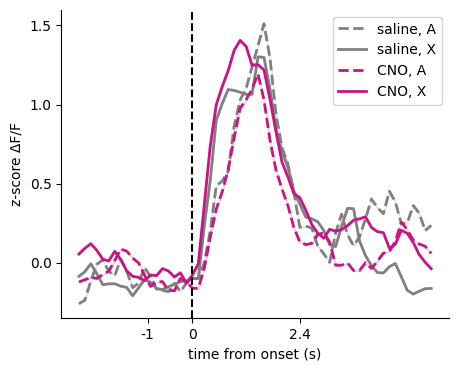

In [288]:
tst = [4]
ctl =[5]

fig, axes = plt.subplots(1, 1, figsize=(5,4))
sal = []
sal_unpred = []
for _,ani in enumerate(ctl):
    trials = data[ani]['unpred_trials']['gr_2'][:4]
    sal.append(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,trials,:].mean(axis=(1,0)) )
    sal_unpred.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X']][:,trials,:].mean(axis=(1,0)) )

viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(sal),color='grey',label='saline, A',style='dash')
viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(sal_unpred),color='grey',label='saline, X')

cno = []
cno_unpred = []
for _,ani in enumerate(tst):
    trials = data[ani]['unpred_trials']['gr_2'][:4]
    cno.append(data[ani]['activity']['gr_1'][sig_cells[ani]['gr_1']][:,trials,:].mean(axis=(1,0)) )
    cno_unpred.append(data[ani]['activity']['gr_2'][sig_cells[ani]['X']][:,trials,:].mean(axis=(1,0)) )

viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(cno),color='mediumvioletred',label='CNO, A',style='dash')
viz.plot_shaded_error(axes,x_vals=np.arange(60),data=np.vstack(cno_unpred),color='mediumvioletred',label='CNO, X')

axes.set_ylabel('z-score ΔF/F')
axes.set_yticks([0,0.5,1,1.5])
axes.set_xticks([11.5, 19, 37])
axes.set_xticklabels(['-1', '0', '2.4'])
axes.axvline(19, linestyle='--', color='k')
axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)
axes.set_xlabel('time from onset (s)')
# axes.set_title('grating 2')


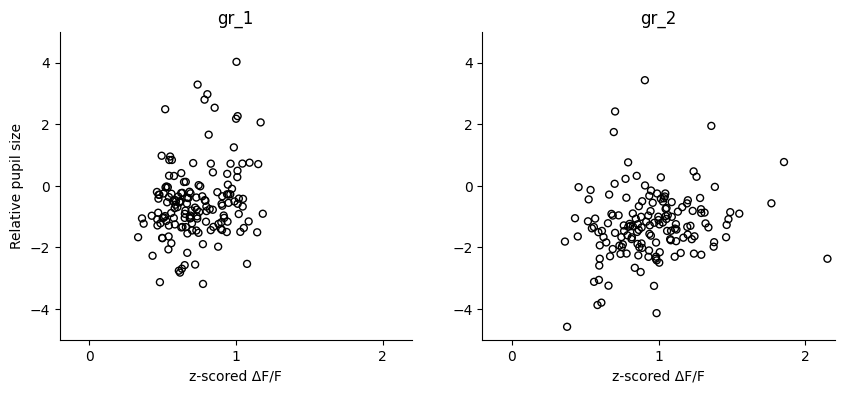

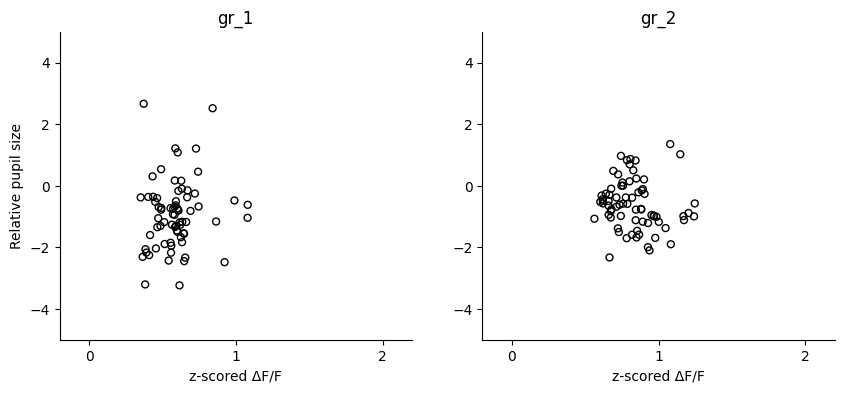

In [339]:
# correlation between pupil and V1 activity (post stimulus)
tst = [4]
ctl = [5]

exp_tri = {}
for ani in ani_range:
    exp_tri[ani] = np.setdiff1d(np.arange(170), unexp_tri[ani])

for i, trials in enumerate([exp_tri[ani],unexp_tri[ani]]):

    fig,axes = plt.subplots(1,2, figsize = (10,4))
    ax=axes[0]
    pupil_post = []
    activity_post = []
    grat = 'gr_1'
    for ani in ctl:
        pupil_post.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][trials,poststim_frames], axis=1))
        activity_post.append(data[ani]['activity'][grat][sig_cells[ani][grat]][:,trials,poststim_frames].mean(axis=(0,2)))

    activity_post = np.concatenate(activity_post)
    pupil_post = np.concatenate(pupil_post)

    mask = np.isfinite(pupil_post) & np.isfinite(activity_post)
    ax.scatter(activity_post[mask], pupil_post[mask], facecolor='none', edgecolor='black', s=25)
    ax.set_xlabel('z-scored ΔF/F')
    ax.set_ylabel('Relative pupil size')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([0,1,2])
    ax.set_xlim([-0.2,2.2])
    ax.set_ylim([-5,5])
    ax.set_title(grat)

    ax = axes[1]
    pupil_post = []
    activity_post = []
    grat = 'gr_2'
    if i == 0:
        for ani in ctl:
            pupil_post.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][trials,poststim_frames], axis=1))
            activity_post.append(data[ani]['activity'][grat][sig_cells[ani][grat]][:,trials,poststim_frames].mean(axis=(0,2)))
    else:
        for ani in ctl:
            pupil_post.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][trials,poststim_frames], axis=1))
            activity_post.append(data[ani]['activity'][grat][sig_cells[ani]['X']][:,trials,poststim_frames].mean(axis=(0,2)))            

    activity_post = np.concatenate(activity_post)
    pupil_post = np.concatenate(pupil_post)

    mask = np.isfinite(pupil_post) & np.isfinite(activity_post)
    ax.scatter(activity_post[mask], pupil_post[mask], facecolor='none', edgecolor='black', s=25)
    ax.set_xlabel('z-scored ΔF/F')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_ylabel('Relative pupil size')
    ax.set_xticks([0,1,2])
    ax.set_xlim([-0.2,2.2])
    ax.set_ylim([-5,5])
    ax.set_title(grat)
    plt.show()

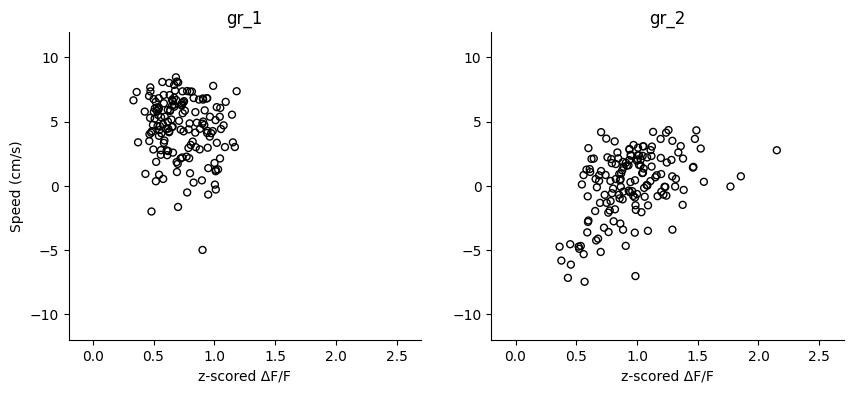

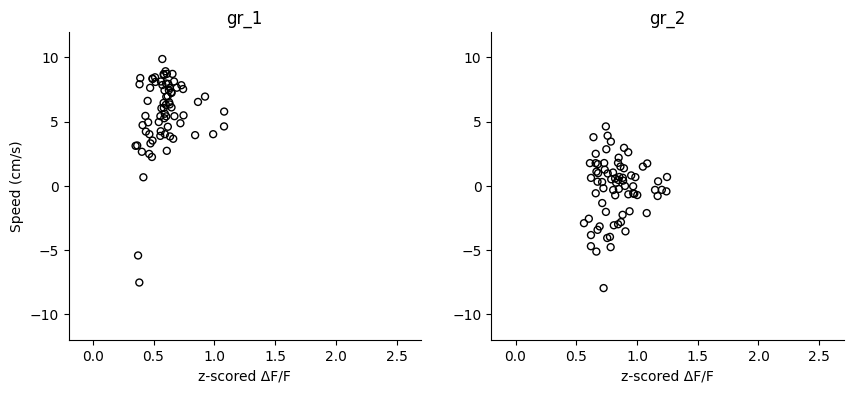

In [355]:
# correlation between speed and V1 activity (post stimulus)
tst = [4]
ctl = [5]

exp_tri = {}
for ani in ani_range:
    exp_tri[ani] = np.setdiff1d(np.arange(170), unexp_tri[ani])

for i, trials in enumerate([exp_tri[ani],unexp_tri[ani]]):

    fig,axes = plt.subplots(1,2, figsize = (10,4))
    ax=axes[0]
    speed_post = []
    activity_post = []
    grat = 'gr_1'
    for ani in ctl:
        speed_post.append(np.nanmean(data[ani]['speed_cm_s'][grat][trials,poststim_frames], axis=1))
        activity_post.append(data[ani]['activity'][grat][sig_cells[ani][grat]][:,trials,poststim_frames].mean(axis=(0,2)))

    activity_post = np.concatenate(activity_post)
    speed_post = np.concatenate(speed_post)

    mask = np.isfinite(speed_post) & np.isfinite(activity_post)
    ax.scatter(activity_post[mask], speed_post[mask], facecolor='none', edgecolor='black', s=25)
    ax.set_xlabel('z-scored ΔF/F')
    ax.set_ylabel('Speed (cm/s)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_xticks([0,1,2])
    ax.set_xlim([-0.2,2.7])
    ax.set_ylim([-12,12])
    ax.set_title(grat)

    ax = axes[1]
    speed_post = []
    activity_post = []
    grat = 'gr_2'
    if i == 0:
        for ani in ctl:
            speed_post.append(np.nanmean(data[ani]['speed_cm_s'][grat][trials,poststim_frames], axis=1))
            activity_post.append(data[ani]['activity'][grat][sig_cells[ani][grat]][:,trials,poststim_frames].mean(axis=(0,2)))
    else:
        for ani in ctl:
            speed_post.append(np.nanmean(data[ani]['speed_cm_s'][grat][trials,poststim_frames], axis=1))
            activity_post.append(data[ani]['activity'][grat][sig_cells[ani]['X']][:,trials,poststim_frames].mean(axis=(0,2)))            

    activity_post = np.concatenate(activity_post)
    speed_post = np.concatenate(speed_post)

    mask = np.isfinite(speed_post) & np.isfinite(activity_post)
    ax.scatter(activity_post[mask], speed_post[mask], facecolor='none', edgecolor='black', s=25)
    ax.set_xlabel('z-scored ΔF/F')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_ylabel('Relative pupil size')
    # ax.set_xticks([0,1,2])
    ax.set_xlim([-0.2,2.7])
    ax.set_ylim([-12,12])
    ax.set_title(grat)
    plt.show()

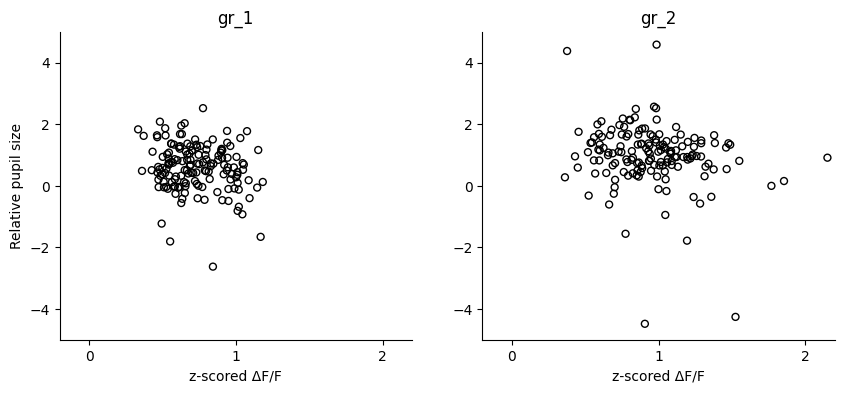

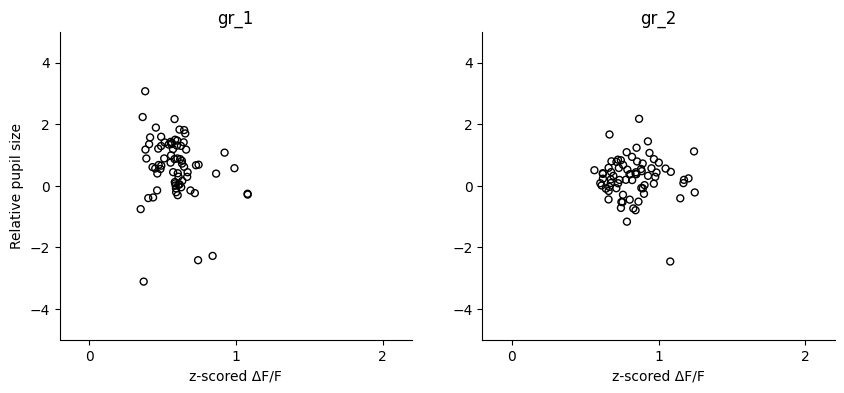

In [ ]:
# correlation between delta pupil and V1 activity (post stimulus)
tst = [4]
ctl = [5]

exp_tri = {}
for ani in ani_range:
    exp_tri[ani] = np.setdiff1d(np.arange(170), unexp_tri[ani])

for i, trials in enumerate([exp_tri[ani],unexp_tri[ani]]):

    fig,axes = plt.subplots(1,2, figsize = (10,4))
    ax=axes[0]
    pupil_delta = []
    activity_post = []
    grat = 'gr_1'
    for ani in ctl:
        pupil_delta.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][trials,prestim_frames], axis=1) - np.nanmean(data[ani]['pupil_rel_bs'][grat][trials,poststim_frames], axis=1))
        activity_post.append(data[ani]['activity'][grat][sig_cells[ani][grat]][:,trials,poststim_frames].mean(axis=(0,2)))

    activity_post = np.concatenate(activity_post)
    pupil_delta = np.concatenate(pupil_delta)

    mask = np.isfinite(pupil_delta) & np.isfinite(activity_post)
    ax.scatter(activity_post[mask], pupil_delta[mask], facecolor='none', edgecolor='black', s=25)
    ax.set_xlabel('z-scored ΔF/F')
    ax.set_ylabel('Relative pupil size')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks([0,1,2])
    ax.set_xlim([-0.2,2.2])
    ax.set_ylim([-5,5])
    ax.set_title(grat)

    ax = axes[1]
    pupil_delta = []
    activity_post = []
    grat = 'gr_2'
    if i == 0:
        for ani in ctl:
            pupil_delta.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][trials,prestim_frames], axis=1) - np.nanmean(data[ani]['pupil_rel_bs'][grat][trials,poststim_frames], axis=1))
            activity_post.append( data[ani]['activity'][grat][sig_cells[ani][grat]][:,trials,poststim_frames].mean(axis=(0,2)))
    else:
        for ani in ctl:
            pupil_delta.append(np.nanmean(data[ani]['pupil_rel_bs'][grat][trials,prestim_frames], axis=1) - np.nanmean(data[ani]['pupil_rel_bs'][grat][trials,poststim_frames], axis=1))
            activity_post.append( data[ani]['activity'][grat][sig_cells[ani]['X']][:,trials,poststim_frames].mean(axis=(0,2)))         

    activity_post = np.concatenate(activity_post)
    pupil_delta = np.concatenate(pupil_delta)

    mask = np.isfinite(pupil_delta) & np.isfinite(activity_post)
    ax.scatter(activity_post[mask], pupil_delta[mask], facecolor='none', edgecolor='black', s=25)
    ax.set_xlabel('z-scored ΔF/F')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_ylabel('Relative pupil size')
    ax.set_xticks([0,1,2])
    ax.set_xlim([-0.2,2.2])
    ax.set_ylim([-5,5])
    ax.set_title(grat)
    plt.show()

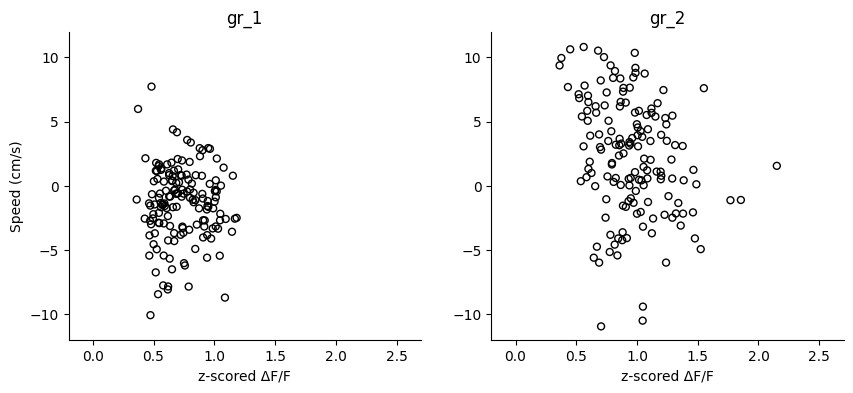

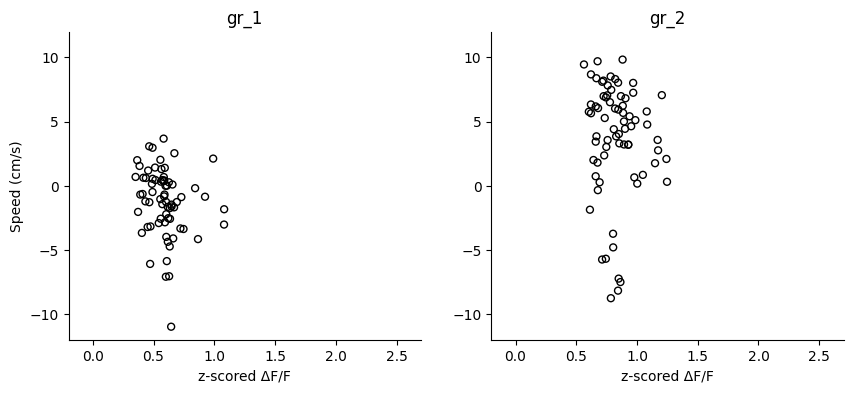

In [356]:
# correlation between delta speed and V1 activity (post stimulus)
tst = [4]
ctl = [5]

exp_tri = {}
for ani in ani_range:
    exp_tri[ani] = np.setdiff1d(np.arange(170), unexp_tri[ani])

for i, trials in enumerate([exp_tri[ani],unexp_tri[ani]]):

    fig,axes = plt.subplots(1,2, figsize = (10,4))
    ax=axes[0]
    speed_delta = []
    activity_post = []
    grat = 'gr_1'
    for ani in ctl:
        speed_delta.append(np.nanmean(data[ani]['speed_cm_s'][grat][trials,prestim_frames], axis=1) - np.nanmean(data[ani]['speed_cm_s'][grat][trials,poststim_frames], axis=1))
        activity_post.append(data[ani]['activity'][grat][sig_cells[ani][grat]][:,trials,poststim_frames].mean(axis=(0,2)))

    activity_post = np.concatenate(activity_post)
    speed_delta = np.concatenate(speed_delta)

    mask = np.isfinite(speed_delta) & np.isfinite(activity_post)
    ax.scatter(activity_post[mask], speed_delta[mask], facecolor='none', edgecolor='black', s=25)
    ax.set_xlabel('z-scored ΔF/F')
    ax.set_ylabel('Speed (cm/s)')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_xticks([0,1,2])
    ax.set_xlim([-0.2,2.7])
    ax.set_ylim([-12,12])
    ax.set_title(grat)

    ax = axes[1]
    speed_delta = []
    activity_post = []
    grat = 'gr_2'
    if i == 0:
        for ani in ctl:
            speed_delta.append(np.nanmean(data[ani]['speed_cm_s'][grat][trials,prestim_frames], axis=1) - np.nanmean(data[ani]['speed_cm_s'][grat][trials,poststim_frames], axis=1))
            activity_post.append(data[ani]['activity'][grat][sig_cells[ani][grat]][:,trials,poststim_frames].mean(axis=(0,2)))
    else:
        for ani in ctl:
            speed_delta.append(np.nanmean(data[ani]['speed_cm_s'][grat][trials,prestim_frames], axis=1) - np.nanmean(data[ani]['speed_cm_s'][grat][trials,poststim_frames], axis=1))
            activity_post.append(data[ani]['activity'][grat][sig_cells[ani]['X']][:,trials,poststim_frames].mean(axis=(0,2)))            

    activity_post = np.concatenate(activity_post)
    speed_delta = np.concatenate(speed_delta)

    mask = np.isfinite(speed_delta) & np.isfinite(activity_post)
    ax.scatter(activity_post[mask], speed_delta[mask], facecolor='none', edgecolor='black', s=25)
    ax.set_xlabel('z-scored ΔF/F')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_ylabel('Relative pupil size')
    # ax.set_xticks([0,1,2])
    ax.set_xlim([-0.2,2.7])
    ax.set_ylim([-12,12])
    ax.set_title(grat)
    plt.show()

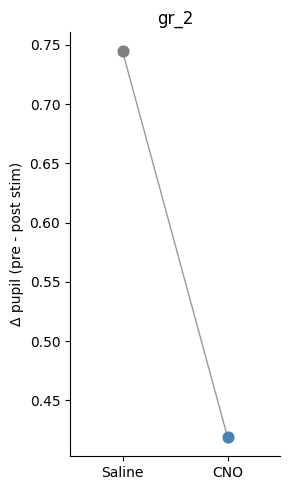

In [357]:
ctl = [5]
tst = [4]

grat = 'gr_2'
sal_means = [np.nanmean(
    np.nanmean(data[ani]['pupil_rel_bs'][grat][:,prestim_frames], axis=1) -
    np.nanmean(data[ani]['pupil_rel_bs'][grat][:,poststim_frames], axis=1)
) for ani in ctl]
cno_means = [np.nanmean(
    np.nanmean(data[ani]['pupil_rel_bs'][grat][:,prestim_frames], axis=1) -
    np.nanmean(data[ani]['pupil_rel_bs'][grat][:,poststim_frames], axis=1)
) for ani in tst]

fig, ax = plt.subplots(figsize=(3, 5))

for sv, cv in zip(sal_means, cno_means):
    ax.plot([1, 2], [sv, cv], color='k', alpha=0.4, linewidth=1)
ax.scatter([1]*len(sal_means), sal_means, s=60, color='grey', zorder=5)
ax.scatter([2]*len(cno_means), cno_means, s=60, color='steelblue', zorder=5)

ax.set_xlim([0.5, 2.5])
ax.set_xticks([1, 2])
ax.set_xticklabels(['Saline', 'CNO'])
ax.set_ylabel('Δ pupil (pre - post stim)')
ax.set_title(grat)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [359]:
#  Run roicat again
# RELOAD 
importlib.reload(preprocess)
data_dir = r'Y:\\public\\projects\SaEl_20220201_VIP\\2pdata\subj_record.xlsx'
sheet_name = 'LC_DREADDs'
table = pd.read_excel(data_dir, sheet_name=sheet_name)
comb = {}
neuropil_factor = 0.3
tri_perc = 1
for ani in [4,5]:
    # Run preprocessing for each animal/session
    ani, pp = preprocess.main(ani, table,sheet_name, neuropil_factor, tri_perc,basesub=1, roitype='aligned')
    comb[ani] = {
        'n_gratings': pp.n_gratings,
        'unpred_trials': pp.unpred_trials,
        'pred_trials': pp.pred_trials,
        'trial_start_indices': pp.trial_start_indices,
        'grating_indices': pp.grating_indices,
        'dff_Zscore': pp.dff_Zscore,
        'n_planes': pp.n_planes,
        'n_trial': pp.n_trials,
        'aligned_data': pp.aligned_data,
        'reward_indices': pp.reward_indices,
        'activity': pp.activity,
        'TC': pp.TC,
        'position': pp.position,
        'position_tunnel': pp.position_tunnel,
        'speed': pp.speed,
        'trial_type': pp.trial_types,
        'pupil': pp.pupil,
        'lick': pp.lick
    }

data = {}
importlib.reload(iv)
for ani in comb.keys():
    data[ani] ={}
    data[ani]['aligned_data'] = comb[ani]['aligned_data']
    data[ani]['activity'] = comb[ani]['activity']
    data[ani]['unpred_trials'] = comb[ani]['unpred_trials']
    data[ani]['pred_trials'] = comb[ani]['pred_trials']
    data[ani]['dff_Zscore'] = comb[ani]['dff_Zscore']
    data[ani]['trial_start_indices'] = comb[ani]['trial_start_indices']
    data[ani]['type'] = table.iloc[ani][3]
    data[ani]['grating_indices']= comb[ani]['grating_indices']
    data[ani]['reward_indices']= comb[ani]['reward_indices']
    data[ani]['n_gratings'] = comb[ani]['n_gratings']
    data[ani]['n_trial'] = comb[ani]['n_trial']
    if table.iloc[ani][1] == 1:
        data[ani]['position_tunnel'] = comb[ani]['position_tunnel']
        data[ani]['position'] = comb[ani]['position']
        data[ani]['speed'] = comb[ani]['speed']
        data[ani]['lick'] = comb[ani]['lick']
        data[ani]['pupil'] = comb[ani]['pupil']
    else:
        data[ani]['position'] = comb[ani]['aligned_data' ]['Averaged_Position']
        try:
            data[ani]['pupil'] = comb[ani]['aligned_data']['pupil_diameter']
            data[ani] = iv.process_pupil(data[ani])
        except KeyError:
            data[ani]['pupil'] = None

        data[ani]['speed'] = comb[ani]['aligned_data']['Speed_Absolute']
        data[ani] = iv.process_speed(data[ani])

    save_pickle(data[ani], "all_data_aligned", base_path=table.iloc[ani][2])

R2=0.9999999922470187 ---- Slope=1.0000167188209355 ---- intercept=0.7651887134620665
Using DLC file: PupilCamera_CameraVideoDLC_resnet50_pupil-setup2-bonsaiJan21shuffle1_500000.csv
Detected 1 excess frames in the downsampled data. Discarding these frames.
bonsai done
R2=0.9999999947148255 ---- Slope=1.000013230245732 ---- intercept=0.7012166481567874
Using DLC file: PupilCamera_CameraVideoDLC_resnet50_pupil-setup2-bonsaiJan21shuffle1_500000.csv
Detected 1 excess frames in the downsampled data. Discarding these frames.
bonsai done


In [360]:
# LOAD DATA
importlib.reload(preprocess)
data_dir = r'Y:\\public\\projects\SaEl_20220201_VIP\\2pdata\subj_record.xlsx'
sheet_name = 'LC_DREADDs'
table = pd.read_excel(data_dir, sheet_name=sheet_name)
data = {}
tri_perc = 1
ani_range = [4,5]
for ani in ani_range:
    data[ani] = load_pickle('all_data_aligned',base_path=table.iloc[ani][2])

In [ ]:
# find responsive cells
blo1 = {}
blo2 = {}
blo1[4] = slice(0,160)
blo1[5] = slice(0,170)
blo2[4] = slice(160,None)
blo2[5] = slice(170,None)

prestim_frames = slice(10,15)
poststim_frames = slice(23,33)
sig_cells = {}
for ani in ani_range:
    sig_cells[ani] = {}
    for grat in ['gr_1','gr_2','X']:
        if grat == 'gr_1':
            sig_cells_blo1 = af.find_significant_neurons_threshold(data[ani]['activity'][grat],blo1[ani],0.5,prestim_frames,poststim_frames)[0]
            sig_cells_blo2 = af.find_significant_neurons_threshold(data[ani]['activity'][grat],blo2[ani],0.5,prestim_frames,poststim_frames)[0]
            sig_cells[ani][grat] = np.union1d(sig_cells_blo1,sig_cells_blo2)  # find sig cells in either blo1 or blo2 or both      
        if grat == 'gr_2':
            trials = data[ani]['pred_trials']
            sig_cells[ani][grat] = af.find_significant_neurons_threshold(data[ani]['activity'][grat],trials,0.5,prestim_frames,poststim_frames)[0]
        if grat == 'X':
            trials = np.array(data[ani]['unpred_trials']['gr_2'])
            trials_blo1 = trials[trials<blo1[ani].stop] # blo1 unexp trials
            trials_blo2 = trials[trials>= blo1[ani].stop] # blo2 unexp trials
            sig_cells_blo1 = af.find_significant_neurons_threshold(data[ani]['activity']['gr_2'],trials_blo1,0.5,prestim_frames,poststim_frames)[0]
            sig_cells_blo2 = af.find_significant_neurons_threshold(data[ani]['activity']['gr_2'],trials_blo2,0.5,prestim_frames,poststim_frames)[0]
            sig_cells[ani][grat] = np.union1d(sig_cells_blo1,sig_cells_blo2)

In [ ]:
for ani in ani_range:
    sig_cells[ani]['all'] = np.union1d(sig_cells[ani]['gr_2'],sig_cells[ani]['X'])  # neurons responsive to gr2 and X

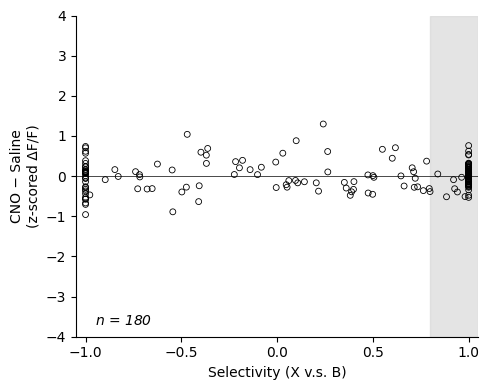

In [425]:
# selectivity index & CNO-saline response to gr_B
si = []
delta_all = [] 
sig_cells_sal = sig_cells[5]['all']  # Use cells that are responsive in saline trials

Xblo2 = data[ani]['activity']['gr_2'][sig_cells_sal][:,blo2[ani],poststim_frames].mean(axis=(1, 2))
Bblo1 = data[ani]['activity']['gr_2'][sig_cells_sal][:,exp_tri[ani],poststim_frames].mean(axis=(1, 2))
si = (Xblo2 - Bblo1) / (Xblo2 + Bblo1)
for i,val in enumerate(si):
    if val>1:
        si[i] = 1
    if val<-1:
        si[i] = -1 

activity_sal = data[5]['activity']['gr_2'][sig_cells_sal][:,exp_tri[ani],poststim_frames].mean(axis=(1,2))
activity_cno = data[4]['activity']['gr_2'][sig_cells_sal][:,exp_tri[ani],poststim_frames].mean(axis=(1,2))
delta = activity_cno - activity_sal
sel_threshold = 0.8
n_cells = len(si)

fig, ax_sc = plt.subplots(1, 1, figsize=(5, 4))

ax_sc.axhline(0, color='k', linewidth=0.5)
ax_sc.axvspan(sel_threshold, 1.05, color='lightgrey', alpha=0.6, zorder=0)

ax_sc.scatter(si, delta,
              facecolor='none', edgecolor='black', s=18, linewidth=0.6)

ax_sc.set_xlabel('Selectivity (X v.s. B)')
ax_sc.set_ylabel('CNO − Saline\n(z-scored ΔF/F)')
ax_sc.set_xlim([-1.05, 1.05])
ax_sc.set_ylim([-4,4])
ax_sc.set_xticks([-1, -0.5, 0, 0.5, 1])

y_min, y_max = ax_sc.get_ylim()
ax_sc.text(-0.95, y_min + 0.3, f'$n$ = {n_cells}', fontsize=10, style='italic')

ax_sc.spines['top'].set_visible(False)
ax_sc.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


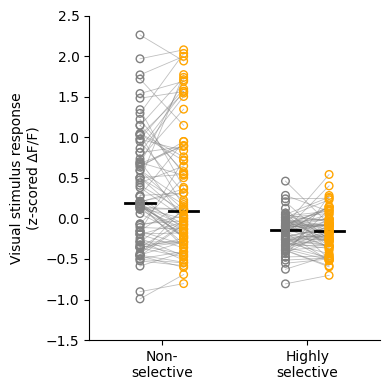

In [437]:
from scipy import stats

mask_non = si < 0.6     # non-selective
mask_sel = si >= 0.8    # highly selective to X

groups  = {'non_sel': mask_non, 'hi_sel': mask_sel}
labels  = ['Non-\nselective', 'Highly\nselective']
x_pos   = [1, 2]
sal_color = 'grey'
cno_color = 'orange'

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

for xi, (grp, mask), label in zip(x_pos, groups.items(), labels):
    sal_vals = activity_sal[mask]
    cno_vals = activity_cno[mask]

    for sv, cv in zip(sal_vals, cno_vals):
        ax.plot([xi - 0.15, xi + 0.15], [sv, cv],
                color='grey', linewidth=0.6, alpha=0.5)

    ax.scatter([xi - 0.15] * len(sal_vals), sal_vals,
               facecolor='none', edgecolor=sal_color, s=30, zorder=4, linewidth=1.0)
    ax.scatter([xi + 0.15] * len(cno_vals), cno_vals,
               facecolor='none', edgecolor=cno_color, s=30, zorder=4, linewidth=1.0)

    ax.plot([xi - 0.25, xi - 0.05], [np.median(sal_vals)] * 2, color='black', linewidth=2)
    ax.plot([xi + 0.05, xi + 0.25], [np.median(cno_vals)] * 2, color='black', linewidth=2)

    # _, p = stats.ttest_rel(sal_vals, cno_vals)
    # y_top = max(sal_vals.max(), cno_vals.max())
    # ax.plot([xi - 0.15, xi + 0.15], [y_top + 0.1, y_top + 0.1], color='k', lw=0.8)
    # ax.text(xi, y_top + 0.15, f'P = {p:.3f}', ha='center', va='bottom', fontsize=8)

ax.scatter([], [], facecolor='none', edgecolor=sal_color, s=30, linewidth=1.0,)
ax.scatter([], [], facecolor='none', edgecolor=cno_color, s=30, linewidth=1.0)
ax.legend(frameon=False, fontsize=9, loc='upper left')

ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel('Visual stimulus response\n(z-scored ΔF/F)')
ax.set_xlim([0.5, 2.5])
ax.set_ylim([-1.5,2.5])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()